In [3]:
## Importer les packages nécessaires
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from numpy.random import uniform

In [4]:
### Générer aléatoirement des données simulées de deux dimension
centres=4
X_train,true_lab=make_blobs(100,centers=centres,random_state=42)

In [5]:
print(X_train)

[[ -9.68512147   5.80867569]
 [ -6.06610997  -8.11097391]
 [ -2.97867201   9.55684617]
 [ -5.47683288  -8.28196066]
 [ -8.4805404    7.88430744]
 [ -7.87016352  -7.44640732]
 [  4.97114227   2.94871481]
 [  4.42020695   2.33028226]
 [  4.73695639   2.94181467]
 [ -3.6601912    9.38998415]
 [ -3.05358035   9.12520872]
 [ -6.65216726  -5.57296684]
 [ -6.35768563  -6.58312492]
 [  3.53354386   0.77696306]
 [ -1.77073104   9.18565441]
 [ -9.90922025   7.80599533]
 [ -8.56163696   8.15070616]
 [  4.56786871   2.97670258]
 [ -9.72218519   7.47724802]
 [ -8.36509013   7.250694  ]
 [ -2.97261532   8.54855637]
 [ -8.91542947   7.66467489]
 [ -9.28484271   8.17992171]
 [  5.00127444   3.51120625]
 [  4.6040528    3.53781334]
 [ -2.96983639  10.07140835]
 [  3.22450809   1.55252436]
 [ -8.21266041   6.46636536]
 [ -9.81300943   8.11060752]
 [ -8.1165779   -8.20056621]
 [ -7.55965191  -6.6478559 ]
 [  4.93599911   2.23422496]
 [ -7.07198816  -6.57856225]
 [ -7.67973218   6.5028406 ]
 [ -0.92998481

C:\Users\hp\AppData\Local\Temp\ipykernel_12768\2161606.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=[X[0] for X in X_train],


<Axes: >

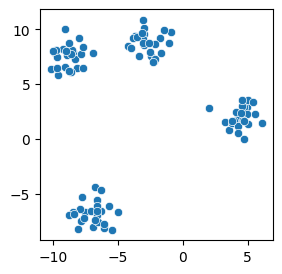

In [6]:
### Illustration graphique
plt.figure(figsize=[3,3])
sns.scatterplot(x=[X[0] for X in X_train],
                y=[X[1] for X in X_train],
                #hue=true_lab,
                #style=true_lab,
                palette="deep",
                legend=None
                )

In [7]:
### Definir la distance euclidienne
def euclid(centre,data):
    return np.sqrt(np.sum((centre-data)**2,axis=1))

In [9]:
### Créer Kmeans from scratch
class Kmeans:
    ##Définir le constructeur
    def __init__(self,n_cl=20,Iter_max=100):
        self.n_cl=n_cl
        self.Iter_max=Iter_max
    ###
    def fit(self,X_train):
        ## Initialisation aléatoire des centres
        min_,max_=np.min(X_train,axis=0),np.max(X_train,axis=0)
        self.centres=[uniform(min_,max_) for _ in range(self.n_cl)]
        ##
        itr=0
        prec_centres=None
        while np.not_equal(self.centres,prec_centres).any() and itr<=self.Iter_max:
            ### Affecter chaque point au groupe de centre gagnant
            grp_points=[[] for _ in range(self.n_cl)]
            for x in X_train:
                dists=euclid(self.centres,x)
                idx=np.argmin(dists)
                #print(idx)
                grp_points[idx].append(x)
            prec_centres=self.centres
            # Calculer les nouveaux centres
            self.centres=[np.mean(groupe,axis=0) for groupe in grp_points]
            ## enumerate retourne l'indice et la valeur de l'indice
            ##Remplacement des centres non définis par les centres précédents pour éviter les valeurs NaN
            for i,centre in enumerate(self.centres):
                if np.isnan(centre).any():
                    self.centres[i]=prec_centres[i]
            
            itr+=1
        #return points_aff
    def evaluation(self,X):
        centres = []
        idxs = []
        for x in X:
            dists = euclid(x, self.centres)
            idx = np.argmin(dists)
            centres.append(self.centres[idx])
            idxs.append(idx)
        return centres, idxs


In [10]:
### Créer et entrainer le modèle Kmeans
km=Kmeans(n_cl=4)
centres=km.fit(X_train)
#print(len(centres[0]))

In [11]:
###
class_centers, classification = km.evaluation(X_train)
print(len(class_centers))
#print(class_centers)
print([x for x, _ in km.centres])
print([y for _, y in km.centres])
print(classification)

100
[-6.9749469009335145, -2.698272507037713, -8.854612195776115, 4.444417646748971]
[-6.764719664988015, 8.743419509848977, 7.548082423511621, 2.0212214813741207]
[2, 0, 1, 0, 2, 0, 3, 3, 3, 1, 1, 0, 0, 3, 1, 2, 2, 3, 2, 2, 1, 2, 2, 3, 3, 1, 3, 2, 2, 0, 0, 3, 0, 2, 1, 1, 1, 1, 3, 3, 2, 3, 0, 1, 1, 0, 0, 2, 2, 3, 3, 3, 3, 0, 2, 2, 1, 1, 3, 1, 0, 3, 2, 0, 2, 2, 0, 2, 3, 0, 3, 0, 2, 1, 0, 2, 0, 2, 0, 0, 3, 0, 1, 2, 1, 1, 1, 0, 1, 3, 3, 0, 1, 0, 1, 1, 1, 3, 2, 3]


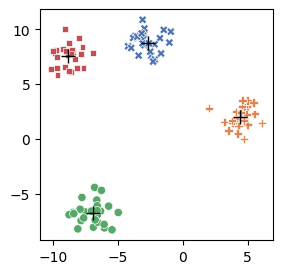

In [12]:
plt.figure(figsize=[3,3])
sns.scatterplot(x=[X[0] for X in X_train],
                y=[X[1] for X in X_train],
                hue=true_lab,
                style=classification,
                palette="deep",
                legend=None
                )
plt.plot([x for x, _ in km.centres],
         [y for _, y in km.centres],
         'k+',
         markersize=10,
         )
plt.show()

In [ ]:
# import numpy as np

# def inertie_intra_classes(X, labels, centroids):
   
#     inertia_intra = 0
#     for i, center in enumerate(centroids):
#         points = X[labels == i]
#         inertia_intra += np.sum((points - center) ** 2)
#     return inertia_intra


# def inertie_inter_classes(X, labels, centroids):
   
#     global_center = np.mean(X, axis=0)
#     inertia_inter = 0
#     for i, center in enumerate(centroids):
#         n_points = np.sum(labels == i)
#         inertia_inter += n_points * np.sum((center - global_center) ** 2)
#     return inertia_inter


1. Ajouter deux fonctions qui calcule l'inertie interclasses et intra classes.

🌀 Itération 1: Intra = 6705.03 | Inter = 10074.58
🌀 Itération 2: Intra = 3846.66 | Inter = 9708.83
🌀 Itération 3: Intra = 3842.79 | Inter = 9518.36
🌀 Itération 4: Intra = 3842.25 | Inter = 9488.13
🌀 Itération 5: Intra = 3840.30 | Inter = 9543.89
🌀 Itération 6: Intra = 3833.43 | Inter = 9513.69
🌀 Itération 7: Intra = 3831.20 | Inter = 9488.77
🌀 Itération 8: Intra = 3830.56 | Inter = 9488.26
🌀 Itération 9: Intra = 3830.29 | Inter = 9464.68
🌀 Itération 10: Intra = 3830.17 | Inter = 9464.04


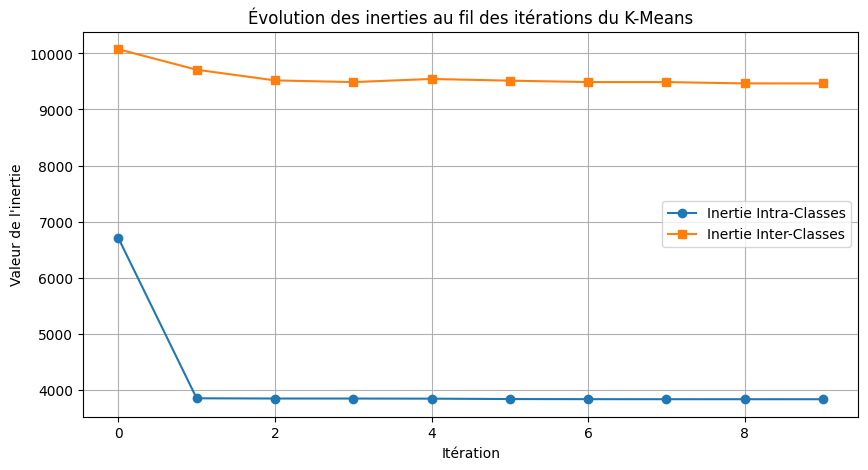

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Fonctions d'inertie ---

def inertie_intra_classes(X, labels, centroids):
    inertia_intra = 0
    for i, center in enumerate(centroids):
        points = X[labels == i]
        inertia_intra += np.sum((points - center) ** 2)
    return inertia_intra


def inertie_inter_classes(X, labels, centroids):
    global_center = np.mean(X, axis=0)
    inertia_inter = 0
    for i, center in enumerate(centroids):
        n_points = np.sum(labels == i)
        inertia_inter += n_points * np.sum((center - global_center) ** 2)
    return inertia_inter

# 2. afficher à chaque itération de l'algorithme de K-means les deux mesures implémentées.
# --- Implémentation manuelle du K-Means pour afficher les inerties à chaque itération ---

def kmeans_inertie_iteration(X, n_clusters=3, max_iter=10, random_state=42):
    np.random.seed(random_state)

    # Initialisation aléatoire des centroïdes
    indices = np.random.choice(len(X), n_clusters, replace=False)
    centroids = X[indices]

    inertie_intra_history = []
    inertie_inter_history = []

    for iteration in range(max_iter):
        # Attribution des points au cluster le plus proche
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Calcul des nouvelles positions des centroïdes
        new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(n_clusters)])

        # Calcul des inerties
        intra = inertie_intra_classes(X, labels, centroids)
        inter = inertie_inter_classes(X, labels, centroids)

        inertie_intra_history.append(intra)
        inertie_inter_history.append(inter)

        print(f"🌀 Itération {iteration+1}: Intra = {intra:.2f} | Inter = {inter:.2f}")

        # Vérifier la convergence
        if np.allclose(centroids, new_centroids):
            print("✅ Convergence atteinte.")
            break

        centroids = new_centroids

    return labels, centroids, inertie_intra_history, inertie_inter_history


# --- Exemple d'exécution avec des données aléatoires ---
from sklearn.datasets import make_blobs

# Générer des données pour le test
X, _ = make_blobs(n_samples=200, centers=3, random_state=42, cluster_std=1.2)

# Lancer le K-Means
labels, centroids, intra_hist, inter_hist = kmeans_inertie_iteration(X, n_clusters=3, max_iter=10)

# --- Visualisation de l'évolution des inerties ---
plt.figure(figsize=(10,5))
plt.plot(intra_hist, label="Inertie Intra-Classes", marker='o')
plt.plot(inter_hist, label="Inertie Inter-Classes", marker='s')
plt.xlabel("Itération")
plt.ylabel("Valeur de l'inertie")
plt.title("Évolution des inerties au fil des itérations du K-Means")
plt.legend()
plt.grid(True)
plt.show()
